## **Energy spectrum and quiver plot of results of inferece from the GNS model on the Kolmogorov dataset**



In [11]:
import sys
import os

import pickle 
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.utils.jax_utils.vis_utils import pos_init_cartesian_2d
from src.utils.jax_utils.vis_utils import mls_2nd_order, energy_spectrum
from src.utils.data_utils import load_metadata

### **Read rollout data from pkl file**

In [22]:
source_path = '../logs/rollouts/ckr4tejc/test'  # KOLM2D rollouts

files = os.listdir(source_path)
files = [f for f in files if f.endswith('.pkl')]
files.sort() 
print(files)

['rollout_0000.pkl', 'rollout_0001.pkl', 'rollout_0002.pkl', 'rollout_0003.pkl', 'rollout_0004.pkl', 'rollout_0005.pkl', 'rollout_0006.pkl', 'rollout_0007.pkl', 'rollout_0008.pkl', 'rollout_0009.pkl', 'rollout_0010.pkl', 'rollout_0011.pkl', 'rollout_0012.pkl', 'rollout_0013.pkl', 'rollout_0014.pkl', 'rollout_0015.pkl', 'rollout_0016.pkl', 'rollout_0017.pkl', 'rollout_0018.pkl', 'rollout_0019.pkl', 'rollout_0020.pkl', 'rollout_0021.pkl', 'rollout_0022.pkl', 'rollout_0023.pkl', 'rollout_0024.pkl', 'rollout_0025.pkl', 'rollout_0026.pkl', 'rollout_0027.pkl', 'rollout_0028.pkl', 'rollout_0029.pkl', 'rollout_0030.pkl', 'rollout_0031.pkl', 'rollout_0032.pkl', 'rollout_0033.pkl', 'rollout_0034.pkl', 'rollout_0035.pkl', 'rollout_0036.pkl', 'rollout_0037.pkl', 'rollout_0038.pkl', 'rollout_0039.pkl', 'rollout_0040.pkl', 'rollout_0041.pkl', 'rollout_0042.pkl', 'rollout_0043.pkl', 'rollout_0044.pkl', 'rollout_0045.pkl', 'rollout_0046.pkl', 'rollout_0047.pkl', 'rollout_0048.pkl', 'rollout_0049.pkl',

In [33]:
e_kin = []

#Compute the kinetic energy of the first frame of each rollout
# for j in range(100):
    # file = files[j]
for file in files:
    trajectory_rollout = os.path.join(source_path, file)
    with open(trajectory_rollout, 'rb') as f:
        rollout = pickle.load(f)
        for frame in range(rollout['predicted_u_vel'].shape[0]):
            e_kin.append((rollout['predicted_u_vel'][frame]**2).sum())
        
print(len(e_kin))
print(rollout.keys())


9880
dict_keys(['predicted_rollout', 'ground_truth_rollout', 'particle_type', 'predicted_u_vel', 'ground_truth_u_vel'])


## Plot kinetic energy 

Text(0.8, 0.1, '$\\propto k^{-3}$')

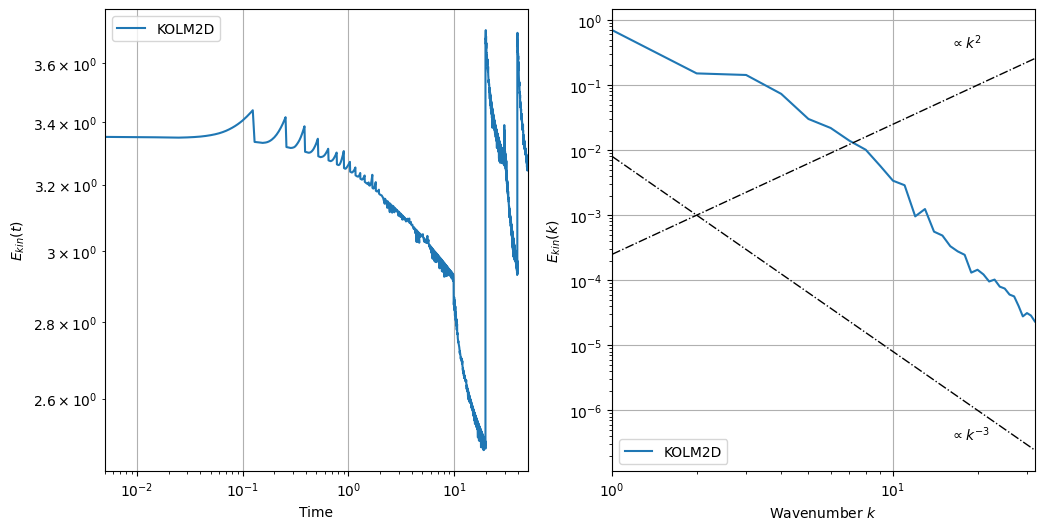

In [34]:
#instead of the cfg, read from the metadata
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
label = "KOLM2D"

metadata = load_metadata('../data/2D_KOLM_4096_20kevery10')
e_kin = 0.5 * np.array(e_kin)/metadata["num_particles_max"]
x_axis = np.arange(len(e_kin))*metadata["dt"]*metadata["write_every"]

dim, dx = metadata["dim"], metadata["dx"]

N = metadata["num_particles_max"]
nx = round(np.sqrt(N))
k_axis = np.arange(1, nx//2+1)
r, u = rollout['predicted_rollout'][0], rollout['predicted_u_vel'][0]  # last state of simulation
box_size = np.array(metadata["bounds"])[:, 1] - np.array(metadata["bounds"])[:, 0]
r_grid = pos_init_cartesian_2d(box_size, dx)
u_mls = np.array([
    mls_2nd_order(r, r_grid, u[:,i], box_size, dx, dim, kernel_name="Quintic") for i in range(dim)
])
spectrum = energy_spectrum(u_mls.reshape(dim, nx, nx))
spectrum *= (1/(4 * np.pi))  # undo normalization to match magnitude from PDF above

axs[0].plot(x_axis[1:], e_kin[1:], label=label)
axs[1].plot(k_axis, spectrum[1:nx//2+1], label=label)

for ax in axs:
    ax.legend()
    ax.grid()
    ax.set_xscale('log')
    ax.set_yscale('log')

axs[0].set_xlabel(r'Time')
axs[0].set_ylabel(r'$E_{kin}(t)$')
axs[1].set_xlabel(r'Wavenumber $k$')
axs[1].set_ylabel(r'$E_{kin}(k)$')
axs[0].set_xlim((x_axis[1], x_axis[-1]))
axs[1].set_xlim((1, nx//2))

axs[1].plot(k_axis, 0.00025 * k_axis**(2.0), '-.', c='k', lw=1)
axs[1].plot(k_axis, 1/125 * k_axis**(-3.0), '-.', c='k', lw=1)
axs[1].text(0.8, 0.95, r"$\propto k^{2}$", ha='left', va='top', transform=ax.transAxes)
axs[1].text(0.8, 0.1, r"$\propto k^{-3}$", ha='left', va='top', transform=ax.transAxes)

### Quiver plot

['rollout_0000.pkl', 'rollout_0001.pkl', 'rollout_0002.pkl', 'rollout_0003.pkl', 'rollout_0004.pkl', 'rollout_0005.pkl', 'rollout_0006.pkl', 'rollout_0007.pkl', 'rollout_0008.pkl', 'rollout_0009.pkl', 'rollout_0010.pkl', 'rollout_0011.pkl', 'rollout_0012.pkl', 'rollout_0013.pkl', 'rollout_0014.pkl', 'rollout_0015.pkl', 'rollout_0016.pkl', 'rollout_0017.pkl', 'rollout_0018.pkl', 'rollout_0019.pkl', 'rollout_0020.pkl', 'rollout_0021.pkl', 'rollout_0022.pkl', 'rollout_0023.pkl', 'rollout_0024.pkl', 'rollout_0025.pkl', 'rollout_0026.pkl', 'rollout_0027.pkl', 'rollout_0028.pkl', 'rollout_0029.pkl', 'rollout_0030.pkl', 'rollout_0031.pkl', 'rollout_0032.pkl', 'rollout_0033.pkl', 'rollout_0034.pkl', 'rollout_0035.pkl', 'rollout_0036.pkl', 'rollout_0037.pkl', 'rollout_0038.pkl', 'rollout_0039.pkl', 'rollout_0040.pkl', 'rollout_0041.pkl', 'rollout_0042.pkl', 'rollout_0043.pkl', 'rollout_0044.pkl', 'rollout_0045.pkl', 'rollout_0046.pkl', 'rollout_0047.pkl', 'rollout_0048.pkl', 'rollout_0049.pkl',

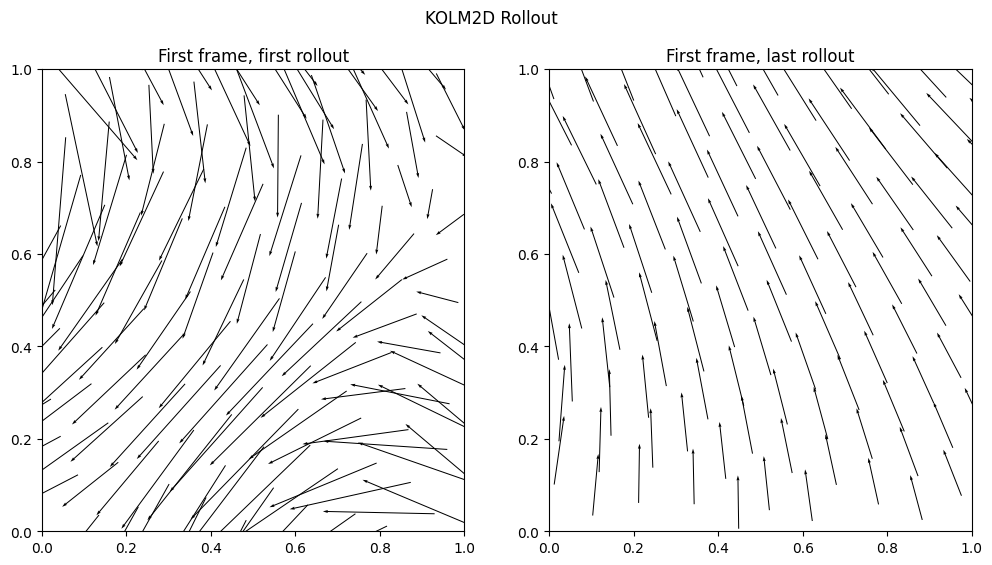

In [6]:
# Define the source path for rollouts
source_path = '../logs/rollouts/ckr4tejc/test'  # KOLM2D rollouts

# Get all .pkl files in the directory
files = os.listdir(source_path)
files = [f for f in files if f.endswith('.pkl')]
files.sort()  # Ensure files are sorted chronologically
print(files)

time_indices = [1, -1]  # Adjust these indices if necessary
time_labels = ["First frame, first rollout", "First frame, last rollout"]

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.suptitle("KOLM2D Rollout")

# Loop through the two frames (matching original behavior)
for ax, file, title in zip(axs, [files[time_indices[0]], files[time_indices[1]]], time_labels):
    single_frame = os.path.join(source_path, file)

    with open(single_frame, 'rb') as f:
        rollout = pickle.load(f)

    # Extract position and velocity
    r, u = rollout['predicted_rollout'][0], rollout['predicted_u_vel'][0]  # first frame

    # Plot velocity field using quiver
    ax.quiver(r[:, 0], r[:, 1], u[:, 0], u[:, 1], scale=10)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.show()


## Animate

In [ ]:
import matplotlib.animation as animation
from IPython.display import Image

# Define the source path for rollouts
source_path = '../logs/rollouts/ckr4tejc/test'  # KOLM2D rollouts

# Get all .pkl files in the directory
files = os.listdir(source_path)
files = [f for f in files if f.endswith('.pkl')]
files.sort()  # Ensure chronological order
print(files)

# Load the first file (assuming all have the same structure)
single_frame = os.path.join(source_path, files[1])
with open(single_frame, 'rb') as f:
    rollout = pickle.load(f)

# Get the total number of timesteps
num_timesteps = rollout["predicted_rollout"].shape[0]  

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Velocity Field Animation")

# Initialize quiver plot
r, u = rollout["predicted_rollout"][0], rollout["predicted_u_vel"][0]
quiver = ax.quiver(r[:, 0], r[:, 1], u[:, 0], u[:, 1], scale=10)

# Animation function
def animate(i):
    r, u = rollout["predicted_rollout"][i], rollout["predicted_u_vel"][i]
    quiver.set_offsets(r)  # Update particle positions
    quiver.set_UVC(u[:, 0], u[:, 1])  # Update velocity vectors
    return quiver,

# Create the animation
ani = animation.FuncAnimation(
    fig, animate, frames=num_timesteps, interval=50, repeat=True
)

# Close the figure (avoid duplicate display)
plt.close(fig)

# Save the animation as a GIF
output_dir = "media"
output_path = os.path.join(output_dir, "velocity_field.gif")
os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
writer = animation.PillowWriter(fps=10, metadata=dict(artist="Me"), bitrate=1800)
ani.save(output_path, writer=writer)

# Display the GIF in the notebook
Image(url=output_path)
